# Threshold Optimization & Cross-Validation
- Find optimal decision threshold
- Perform stratified cross-validation
- Analyze feature importance

## Setup & Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

# Style settings
DARK = {
    "bg": "#0F1117", "panel": "#1A1D27", "grid": "#252836",
    "text": "#E8EAF0", "sub": "#8890A4", "blue": "#4F8EF7",
    "red": "#F7614F", "green": "#4FD1A5", "gold": "#F7C84F",
}

plt.rcParams.update({
    "figure.facecolor": DARK["bg"], "axes.facecolor": DARK["panel"],
    "figure.dpi": 110,
})

SEED = 42
np.random.seed(SEED)

## Load data and model

In [2]:
import joblib
df = pd.read_csv("data/data_feature_engineered.csv")
FEATURES = np.load("data/features_list.npy", allow_pickle=True).tolist()
xgb_model = joblib.load("models/xgboost_model.pkl")
X = df[FEATURES].values
y = df["Is_Fraud"].values

print("Data and model loaded")

Data and model loaded


## Threshold Optimization

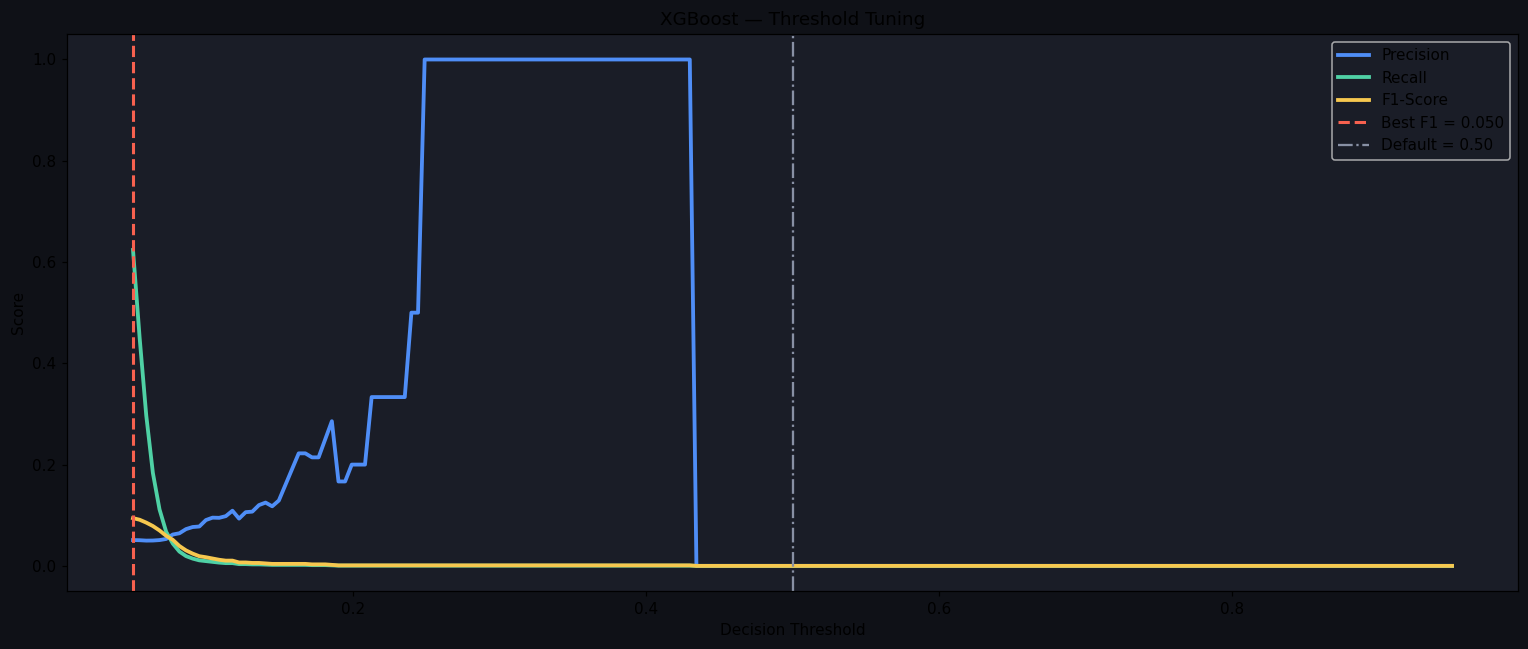

Best F1 threshold: 0.050
F1 at best threshold: 0.0943
Recall at best threshold: 0.6239


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 200)
prec_vals = []
rec_vals = []
f1_vals = []

for t in thresholds:
    preds_t = (xgb_proba >= t).astype(int)
    prec_vals.append(precision_score(y_test, preds_t, zero_division=0))
    rec_vals.append(recall_score(y_test, preds_t, zero_division=0))
    f1_vals.append(f1_score(y_test, preds_t, zero_division=0))

best_f1_idx = np.argmax(f1_vals)
best_t = thresholds[best_f1_idx]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(thresholds, prec_vals, color=DARK["blue"], lw=2.5, label="Precision")
ax.plot(thresholds, rec_vals, color=DARK["green"], lw=2.5, label="Recall")
ax.plot(thresholds, f1_vals, color=DARK["gold"], lw=2.5, label="F1-Score")
ax.axvline(best_t, color=DARK["red"], ls="--", lw=2, label=f"Best F1 = {best_t:.3f}")
ax.axvline(0.5, color=DARK["sub"], ls="-.", lw=1.5, label="Default = 0.50")

ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("XGBoost — Threshold Tuning")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_t:.3f}")
print(f"F1 at best threshold: {f1_vals[best_f1_idx]:.4f}")
print(f"Recall at best threshold: {rec_vals[best_f1_idx]:.4f}")


## Cross-Validation

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Running 5-fold CV on imbalanced data...")
scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"\n5-Fold CV Results:")
print(f"Mean AUC: {scores.mean():.4f} ± {scores.std():.4f}")
print(f"Individual folds: {scores}")

Running 5-fold CV on imbalanced data...

5-Fold CV Results:
Mean AUC: 0.5039 ± 0.0068
Individual folds: [0.49425164 0.50636432 0.50638865 0.51364582 0.49860561]


## Cross-Validation Visualization

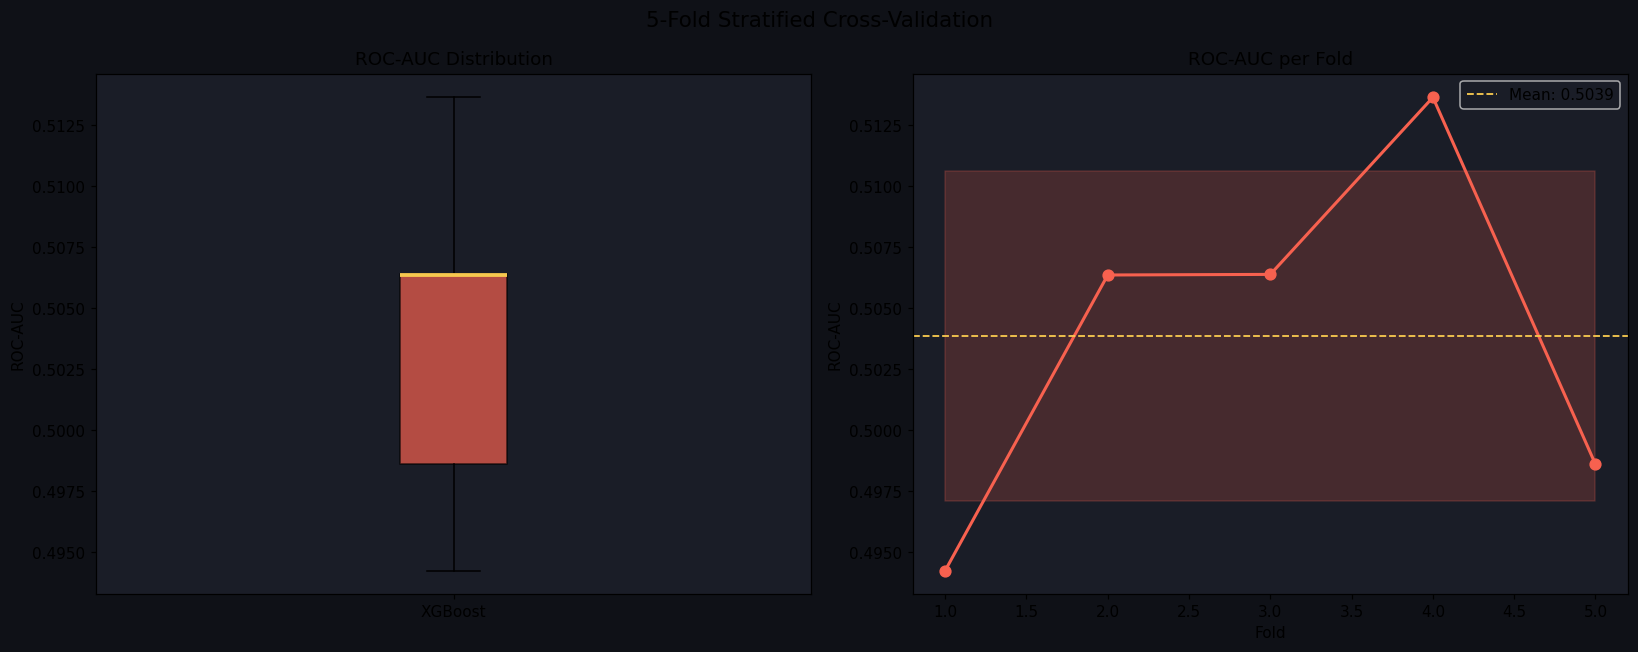

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("5-Fold Stratified Cross-Validation", fontsize=14)

# Box plot
bp = axes[0].boxplot(scores, patch_artist=True,
                     medianprops=dict(color=DARK["gold"], lw=2.5))
bp["boxes"][0].set_facecolor(DARK["red"])
bp["boxes"][0].set_alpha(0.7)
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("ROC-AUC Distribution")
axes[0].set_xticklabels(["XGBoost"])

# Fold-by-fold
fold_nums = np.arange(1, 6)
axes[1].plot(fold_nums, scores, marker="o", ms=7, lw=2, color=DARK["red"])
axes[1].axhline(scores.mean(), color=DARK["gold"], ls="--", lw=1.2, label=f"Mean: {scores.mean():.4f}")
axes[1].fill_between(fold_nums, scores.mean() - scores.std(), scores.mean() + scores.std(),
                      alpha=0.2, color=DARK["red"])
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("ROC-AUC per Fold")
axes[1].legend()

plt.tight_layout()
plt.show()

##  Feature Importance

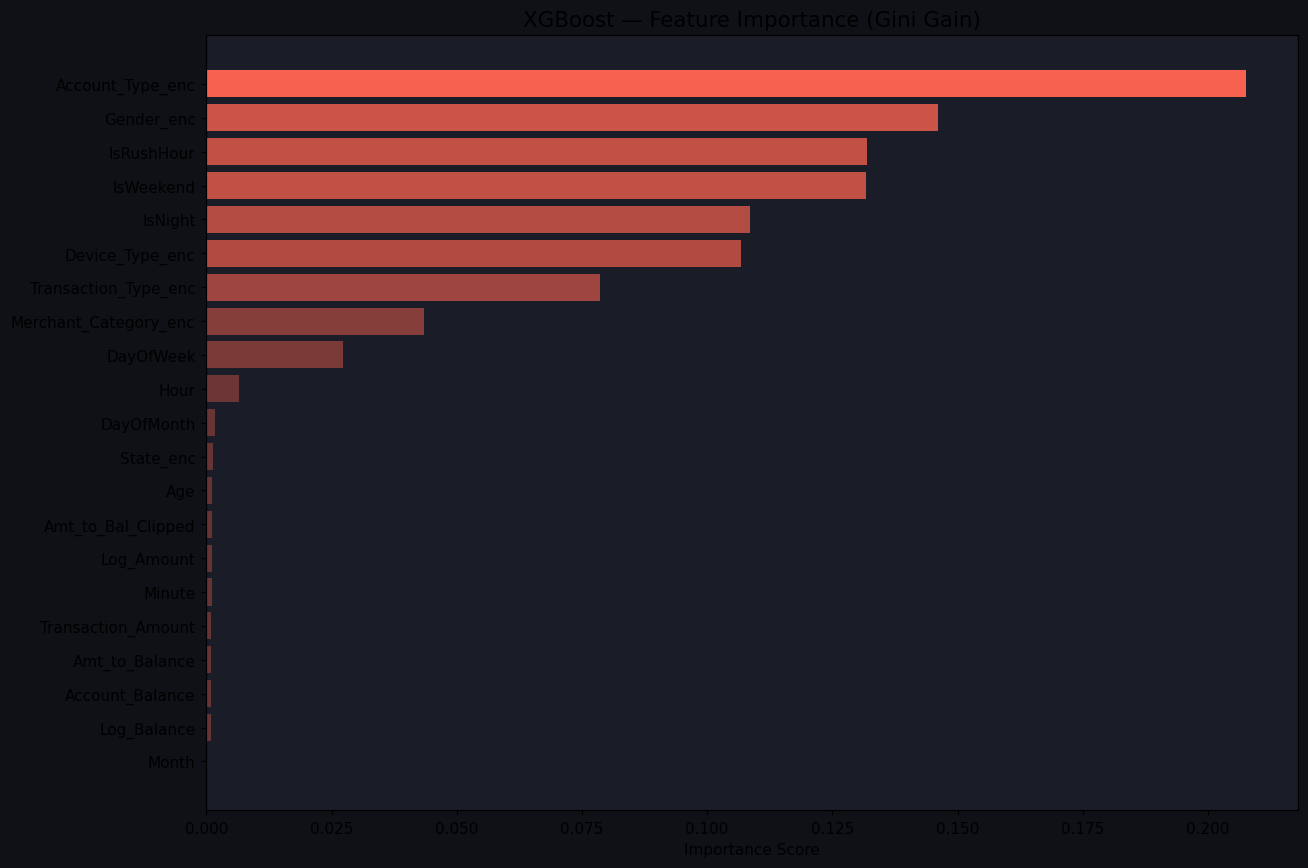


Top 10 Most Important Features:
1. Account_Type_enc: 0.2076
2. Gender_enc: 0.1462
3. IsRushHour: 0.1319
4. IsWeekend: 0.1318
5. IsNight: 0.1086
6. Device_Type_enc: 0.1068
7. Transaction_Type_enc: 0.0787
8. Merchant_Category_enc: 0.0434
9. DayOfWeek: 0.0272
10. Hour: 0.0066


In [6]:
importances = xgb_model.feature_importances_
indices = np.argsort(importances)
feat_names = [FEATURES[i] for i in indices]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(feat_names, importances[indices], color=DARK["red"], edgecolor="none", alpha=0.85)
for bar, v in zip(bars, importances[indices]):
    bar.set_alpha(0.35 + 0.65 * v / importances.max())

ax.set_title("XGBoost — Feature Importance (Gini Gain)", fontsize=14)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
for i in range(10):
    print(f"{i+1}. {feat_names[-i-1]}: {importances[indices[-i-1]]:.4f}")